# Bird Species Audio Classification Training Notebook

This notebook implements a robust end-to-end training pipeline for species identification from audio recordings. It includes dataset preparation, log-mel spectrogram generation, sound event detection modeling, pseudo-label generation, student training, checkpointing, result aggregation, and optional model export.

The training pipeline is organized to support long Kaggle sessions with safer checkpoint saving and resume behavior.


## 1. Environment Setup

Import libraries and check optional dependencies required for audio processing, model training, evaluation, and visualization.


In [10]:
import os
import ast
import gc
import json
import math
import random
import time
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler

try:
    import timm
    TIMM_AVAILABLE = True
except Exception as e:
    TIMM_AVAILABLE = False
    print('timm import failed:', repr(e))

try:
    import torchaudio
    import torchaudio.transforms as AT
    TORCHAUDIO_AVAILABLE = True
except Exception as e:
    TORCHAUDIO_AVAILABLE = False
    print('torchaudio import failed:', repr(e))

try:
    import soundfile as sf
    SOUNDFILE_AVAILABLE = True
except Exception as e:
    SOUNDFILE_AVAILABLE = False
    print('soundfile import failed:', repr(e))

try:
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print('sklearn import failed:', repr(e))

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('timm:', TIMM_AVAILABLE, 'torchaudio:', TORCHAUDIO_AVAILABLE, 'soundfile:', SOUNDFILE_AVAILABLE)


torch: 2.10.0+cu128
cuda available: True
timm: True torchaudio: True soundfile: True


## 2. Configuration

Define project paths, runtime options, audio parameters, model backbones, training hyperparameters, augmentation settings, and pseudo-labeling controls.


In [11]:
@dataclass
class CFG:

    input_root: str = '/kaggle/input'
    manual_dataset_root: Optional[str] = None
    manual_train_csv: Optional[str] = None
    manual_train_audio_dir: Optional[str] = None
    manual_train_soundscape_dir: Optional[str] = None
    output_root: str = '/kaggle/working/birdclef_species_project_v13_safe_resume'

    seed: int = 42
    force_cpu: bool = False
    mixed_precision: bool = True
    num_workers: int = 2

    run_mode: str = 'official_full'
    quick_mode: bool = False
    quick_max_rows: int = 1200
    quick_max_soundscape_windows: int = 300
    quick_backbones: Tuple[str, ...] = ('tf_efficientnet_b0_ns',)
    quick_folds: Tuple[int, ...] = (0,)

    backbones: Tuple[str, ...] = (
        'tf_efficientnetv2_s.in21k',
        'tf_efficientnet_b0_ns',
        'tf_efficientnetv2_b3.in21k',
        'tf_efficientnet_b3_ns',
    )
    folds: int = 5
    folds_to_run: Tuple[int, ...] = (0, 1, 2, 3, 4)

    sample_rate: int = 32000
    wav_sec: float = 5.0
    train_crop_sec: float = 30.0
    n_fft: int = 2048
    win_length: int = 2048
    hop_length: int = 768
    f_min: int = 50
    f_max: int = 15000
    n_mels: int = 192
    mel_power: float = 2.0

    use_secondary_labels: bool = True
    secondary_weight: float = 1.0
    max_classes: Optional[int] = None
    min_primary_count: int = 2

    batch_size: int = 24
    lr: float = 1e-3
    weight_decay: float = 1e-4
    grad_clip: float = 5.0
    epochs_teacher: int = 8
    epochs_student: int = 8
    label_smoothing: float = 0.005
    max_pos_weight: float = 15.0
    use_focal_loss: bool = True
    focal_gamma: float = 2.0

    use_wave_aug: bool = True
    use_spec_aug: bool = True
    use_mixup: bool = True
    mixup_prob: float = 0.5
    mixup_alpha: float = 0.4

    run_pseudo_labeling: bool = True
    pseudo_step_sec: float = 5.0
    pseudo_conf_threshold: float = 0.05
    pseudo_topk: int = 3
    pseudo_soft_clip_min: float = 1e-4
    pseudo_soft_clip_max: float = 1.0 - 1e-4
    student_hard_loss_weight: float = 0.6
    student_pseudo_loss_weight: float = 0.4
    max_soundscape_windows: Optional[int] = None

    skip_existing_checkpoints: bool = True
    save_last_checkpoint: bool = True
    pseudo_save_every_batches: int = 100
    export_openvino: bool = False

cfg = CFG()

if cfg.run_mode == 'project_official_single':
    cfg.quick_mode = False
    cfg.backbones = ('tf_efficientnet_b0_ns',)
    cfg.folds_to_run = (0,)
    cfg.epochs_teacher = 8
    cfg.epochs_student = 8
    cfg.max_soundscape_windows = 5000

if cfg.quick_mode:
    cfg.backbones = cfg.quick_backbones
    cfg.folds_to_run = cfg.quick_folds
    cfg.epochs_teacher = min(cfg.epochs_teacher, 2)
    cfg.epochs_student = min(cfg.epochs_student, 2)
    cfg.batch_size = min(cfg.batch_size, 12)
    cfg.max_soundscape_windows = cfg.quick_max_soundscape_windows

OUTPUT_DIR = Path(cfg.output_root)
MODEL_DIR = OUTPUT_DIR / 'models'
LOG_DIR = OUTPUT_DIR / 'logs'
FIG_DIR = OUTPUT_DIR / 'figures'
INTER_DIR = OUTPUT_DIR / 'intermediate'
for d in [OUTPUT_DIR, MODEL_DIR, LOG_DIR, FIG_DIR, INTER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(cfg)


CFG(input_root='/kaggle/input', manual_dataset_root=None, manual_train_csv=None, manual_train_audio_dir=None, manual_train_soundscape_dir=None, output_root='/kaggle/working/birdclef_species_project_v13_safe_resume', seed=42, force_cpu=False, mixed_precision=True, num_workers=2, run_mode='official_full', quick_mode=False, quick_max_rows=1200, quick_max_soundscape_windows=300, quick_backbones=('tf_efficientnet_b0_ns',), quick_folds=(0,), backbones=('tf_efficientnetv2_s.in21k', 'tf_efficientnet_b0_ns', 'tf_efficientnetv2_b3.in21k', 'tf_efficientnet_b3_ns'), folds=5, folds_to_run=(0, 1, 2, 3, 4), sample_rate=32000, wav_sec=5.0, train_crop_sec=30.0, n_fft=2048, win_length=2048, hop_length=768, f_min=50, f_max=15000, n_mels=192, mel_power=2.0, use_secondary_labels=True, secondary_weight=1.0, max_classes=None, min_primary_count=2, batch_size=24, lr=0.001, weight_decay=0.0001, grad_clip=5.0, epochs_teacher=8, epochs_student=8, label_smoothing=0.005, max_pos_weight=15.0, use_focal_loss=True, fo

## 3. Reproducibility and Hardware Selection

Set random seeds and choose a safe training device. If CUDA is unstable, the notebook automatically falls back to CPU.


In [12]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

def get_device(cfg: CFG):
    if cfg.force_cpu or not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        x = torch.randn(2, 3, 64, 64, device='cuda')
        conv = nn.Conv2d(3, 8, 3, padding=1).cuda()
        y = conv(x)
        torch.cuda.synchronize()
        del x, conv, y
        return torch.device('cuda')
    except Exception as e:
        print('CUDA smoke test failed; falling back to CPU:', repr(e))
        return torch.device('cpu')

device = get_device(cfg)
if device.type == 'cpu':
    cfg.mixed_precision = False
    cfg.num_workers = 0
    cfg.batch_size = min(cfg.batch_size, 4)
print('device:', device)


device: cuda


## 4. Dataset Discovery and Path Mapping

Locate metadata, training audio, and optional soundscape audio from either the standard Kaggle input layout or manually specified paths.


In [13]:
def scan_input(root: Path, max_items: int = 120):
    print('Scanning', root)
    if not root.exists():
        print('Missing input root')
        return
    shown = 0
    for p in sorted(root.rglob('*')):
        print(p)
        shown += 1
        if shown >= max_items:
            print('... truncated')
            break

def find_dataset(cfg: CFG):
    root = Path(cfg.manual_dataset_root) if cfg.manual_dataset_root else Path(cfg.input_root)
    if cfg.manual_train_csv:
        train_csv = Path(cfg.manual_train_csv)
    else:
        candidates = []
        for name in ['train.csv', 'train_metadata.csv']:
            candidates += list(root.rglob(name))
        candidates = sorted(set(candidates), key=lambda p: (0 if 'birdclef-2025' in str(p).lower() else 1, len(str(p))))
        if not candidates:
            scan_input(root)
            raise FileNotFoundError('Could not find train.csv or train_metadata.csv under /kaggle/input. Attach BirdCLEF 2025 dataset or set manual paths in CFG.')
        train_csv = candidates[0]

    base = train_csv.parent
    train_audio = Path(cfg.manual_train_audio_dir) if cfg.manual_train_audio_dir else base / 'train_audio'
    if not train_audio.exists():
        aud_candidates = sorted(base.rglob('train_audio')) + sorted(Path(cfg.input_root).rglob('train_audio'))
        if aud_candidates:
            train_audio = aud_candidates[0]

    soundscapes = Path(cfg.manual_train_soundscape_dir) if cfg.manual_train_soundscape_dir else base / 'train_soundscapes'
    if not soundscapes.exists():
        sc_candidates = sorted(base.rglob('train_soundscapes')) + sorted(Path(cfg.input_root).rglob('train_soundscapes'))
        soundscapes = sc_candidates[0] if sc_candidates else None

    print('train_csv:', train_csv)
    print('train_audio:', train_audio, 'exists:', train_audio.exists())
    print('train_soundscapes:', soundscapes, 'exists:', soundscapes.exists() if soundscapes else False)
    return train_csv, train_audio, soundscapes

train_csv, train_audio_dir, train_soundscape_dir = find_dataset(cfg)
raw_df = pd.read_csv(train_csv)
print(raw_df.shape)
display(raw_df.head())


train_csv: /kaggle/input/competitions/birdclef-2025/train.csv
train_audio: /kaggle/input/competitions/birdclef-2025/train_audio exists: True
train_soundscapes: /kaggle/input/competitions/birdclef-2025/train_soundscapes exists: True
(28564, 13)


,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0


## 5. Metadata Parsing and Multi-Label Target Construction

Parse primary and secondary labels, select the working species set, and construct multi-label target vectors.


In [14]:
def parse_secondary_labels(x: Any) -> List[str]:
    if x is None:
        return []
    if isinstance(x, float) and np.isnan(x):
        return []
    if isinstance(x, list):
        return [str(v) for v in x if str(v) not in ['', 'nan', 'None']]
    s = str(x).strip()
    if s in ['', '[]', 'nan', 'None']:
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(z) for z in v if str(z) not in ['', 'nan', 'None']]
        return [str(v)]
    except Exception:
        return [p.strip() for p in s.replace(';', ',').split(',') if p.strip()]

def infer_filename_column(df: pd.DataFrame) -> str:
    for c in ['filename', 'file_name', 'filepath', 'path', 'audio_path']:
        if c in df.columns:
            return c
    raise ValueError(f'No filename/path column found. Columns: {df.columns.tolist()}')

def resolve_audio_path(row, filename_col: str, train_audio_dir: Path) -> Optional[str]:
    filename = str(row[filename_col])
    primary = str(row.get('primary_label', ''))
    p = Path(filename)
    candidates = []
    if p.is_absolute():
        candidates.append(p)
    candidates += [
        train_audio_dir / filename,
        train_audio_dir / primary / p.name,
        train_audio_dir / p.name,
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    return None

filename_col = infer_filename_column(raw_df)
df = raw_df.copy()
df['primary_label'] = df['primary_label'].astype(str)
df['filepath'] = [resolve_audio_path(row, filename_col, train_audio_dir) for _, row in tqdm(df.iterrows(), total=len(df), desc='resolve audio')]
df = df[df['filepath'].notna()].reset_index(drop=True)
print('rows with audio:', len(df))


if train_audio_dir.exists() and any(p.is_dir() for p in train_audio_dir.iterdir()):
    all_class_labels = sorted([p.name for p in train_audio_dir.iterdir() if p.is_dir()])
else:
    all_class_labels = sorted(df['primary_label'].unique().tolist())

if cfg.max_classes is not None:
    top = df['primary_label'].value_counts().head(cfg.max_classes).index.tolist()
    all_class_labels = [x for x in all_class_labels if x in set(top)]
    df = df[df['primary_label'].isin(all_class_labels)].reset_index(drop=True)

if cfg.quick_mode and cfg.quick_max_rows is not None and len(df) > cfg.quick_max_rows:

    per_class = max(2, math.ceil(cfg.quick_max_rows / max(1, df['primary_label'].nunique())))
    df = (df.groupby('primary_label', group_keys=False)
            .apply(lambda g: g.sample(min(len(g), per_class), random_state=cfg.seed))
            .sample(frac=1, random_state=cfg.seed)
            .head(cfg.quick_max_rows)
            .reset_index(drop=True))

label_to_idx = {l: i for i, l in enumerate(all_class_labels)}
idx_to_label = {i: l for l, i in label_to_idx.items()}
num_classes = len(all_class_labels)

def row_labels(row) -> List[str]:
    labels = []
    p = str(row['primary_label'])
    if p in label_to_idx:
        labels.append(p)
    if cfg.use_secondary_labels and 'secondary_labels' in row:
        for s in parse_secondary_labels(row['secondary_labels']):
            if s in label_to_idx:
                labels.append(s)
    return sorted(set(labels))

df['labels'] = [row_labels(row) for _, row in df.iterrows()]
df = df[df['labels'].map(len) > 0].reset_index(drop=True)


primary_counts = df['primary_label'].value_counts()
keep_primary = primary_counts[primary_counts >= cfg.min_primary_count].index
if len(keep_primary) < len(primary_counts):
    print('Dropping primary labels with too few samples for training split:', len(primary_counts) - len(keep_primary))
    df = df[df['primary_label'].isin(keep_primary)].reset_index(drop=True)

print('working rows:', len(df), 'num_classes:', num_classes)
display(df[['primary_label', 'labels', 'filepath']].head())

with open(OUTPUT_DIR / 'label_to_idx.json', 'w') as f:
    json.dump(label_to_idx, f, indent=2)


resolve audio:   0%|          | 0/28564 [00:00<?, ?it/s]

rows with audio: 28564
working rows: 28564 num_classes: 206


,primary_label,labels,filepath
0,1139490,[1139490],/kaggle/input/competitions/birdclef-2025/train...
1,1139490,[1139490],/kaggle/input/competitions/birdclef-2025/train...
2,1192948,[1192948],/kaggle/input/competitions/birdclef-2025/train...
3,1192948,[1192948],/kaggle/input/competitions/birdclef-2025/train...
4,1192948,[1192948],/kaggle/input/competitions/birdclef-2025/train...


## 6. Cross-Validation Split

Create stratified folds using the primary species label while keeping recording-level samples separated between training and validation.


n_splits: 2 min class count: 2
fold
0    14282
1    14282
Name: count, dtype: int64
target matrix: (28564, 206) positive labels: 32505


,positive_count
grekis,1479.0
trokin,975.0
whtdov,881.0
compau,852.0
banana,714.0
roahaw,711.0
socfly1,618.0
soulap1,601.0
bobfly1,576.0
yeofly1,551.0


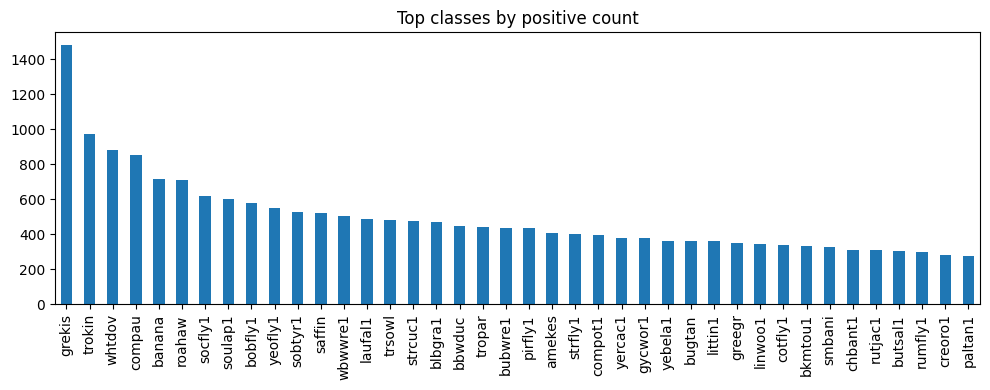

In [15]:
def make_folds(df: pd.DataFrame, cfg: CFG) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    counts = df['primary_label'].value_counts()
    min_count = int(counts.min())
    n_splits = max(2, min(cfg.folds, min_count))
    print('n_splits:', n_splits, 'min class count:', min_count)
    df['fold'] = -1
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=cfg.seed)
    for fold, (_, va_idx) in enumerate(skf.split(df, df['primary_label'])):
        df.loc[va_idx, 'fold'] = fold
    return df

train_df = make_folds(df, cfg)
print(train_df['fold'].value_counts().sort_index())

def make_target_vector(labels: Sequence[str]) -> np.ndarray:
    y = np.zeros(num_classes, dtype=np.float32)
    for l in labels:
        if l in label_to_idx:
            y[label_to_idx[l]] = 1.0
    return y

target_matrix = np.stack([make_target_vector(x) for x in train_df['labels']])
print('target matrix:', target_matrix.shape, 'positive labels:', int(target_matrix.sum()))
class_counts = pd.Series(target_matrix.sum(axis=0), index=all_class_labels).sort_values(ascending=False)
display(class_counts.head(20).to_frame('positive_count'))

plt.figure(figsize=(10,4))
class_counts.head(40).plot(kind='bar')
plt.title('Top classes by positive count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_distribution.png', dpi=160)
plt.show()


## 7. Audio Preprocessing and Log-Mel Spectrogram Generation

Convert waveform clips into normalized log-mel spectrograms using a fixed 32 kHz sample rate and 5-second windows.


mel shape: (1, 192, 209)


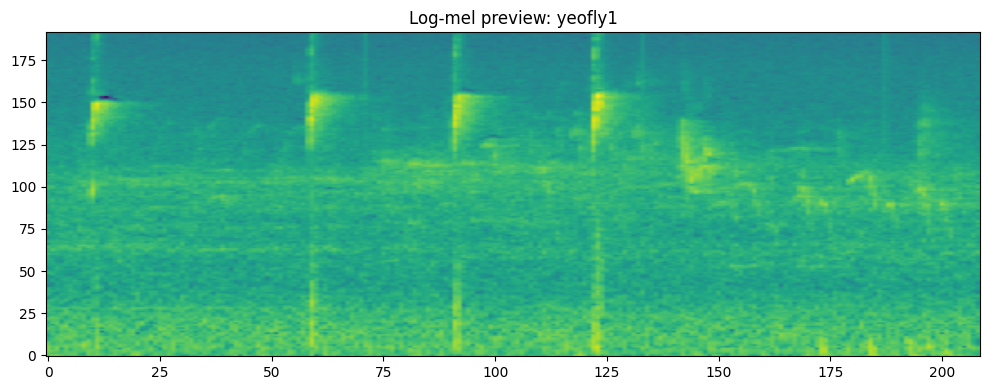

In [16]:
assert TORCHAUDIO_AVAILABLE, 'This notebook requires torchaudio.'

mel_transform = AT.MelSpectrogram(
    sample_rate=cfg.sample_rate,
    n_fft=cfg.n_fft,
    win_length=cfg.win_length,
    hop_length=cfg.hop_length,
    center=True,
    f_min=cfg.f_min,
    f_max=cfg.f_max,
    pad_mode='reflect',
    power=cfg.mel_power,
    norm='slaney',
    n_mels=cfg.n_mels,
    mel_scale='htk',
)

def normalize_std(spec: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    mean = torch.mean(spec)
    std = torch.std(spec)
    return torch.where(std == 0, spec - mean, (spec - mean) / (std + eps))

def load_waveform(path: str, target_sr: int) -> torch.Tensor:
    waveform, sr = torchaudio.load(path, backend='soundfile')
    if waveform.ndim == 2 and waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    elif waveform.ndim == 1:
        waveform = waveform.reshape(1, -1)
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform, orig_freq=sr, new_freq=target_sr)
    return waveform.float()

def crop_or_pad_waveform(waveform: torch.Tensor, target_len: int, start_sample: Optional[int] = None, random_crop: bool = False) -> torch.Tensor:
    n = waveform.shape[1]
    if n < target_len:
        pad = target_len - n
        waveform = F.pad(waveform, (0, pad))
        return waveform
    if n == target_len:
        return waveform
    if start_sample is None:
        if random_crop:
            start_sample = random.randint(0, n - target_len)
        else:
            start_sample = max(0, (n - target_len) // 2)
    start_sample = int(max(0, min(start_sample, n - target_len)))
    return waveform[:, start_sample:start_sample + target_len]

def wave_augment(waveform: torch.Tensor) -> torch.Tensor:

    if random.random() < 0.5:
        gain = random.uniform(0.75, 1.25)
        waveform = waveform * gain
    if random.random() < 0.35:
        noise = torch.randn_like(waveform) * random.uniform(0.0005, 0.004)
        waveform = waveform + noise
    return torch.clamp(waveform, -1.0, 1.0)

def spec_augment(spec: torch.Tensor) -> torch.Tensor:

    _, m, t = spec.shape
    if random.random() < 0.5:
        width = random.randint(0, max(1, m // 8))
        start = random.randint(0, max(0, m - width))
        spec[:, start:start+width, :] = 0
    if random.random() < 0.5:
        width = random.randint(0, max(1, t // 8))
        start = random.randint(0, max(0, t - width))
        spec[:, :, start:start+width] = 0
    return spec

def waveform_to_logmel(waveform: torch.Tensor) -> torch.Tensor:

    mx = torch.max(torch.abs(waveform))
    if mx > 0:
        waveform = waveform / mx
    spec = mel_transform(waveform)
    spec = 10.0 * torch.log10(torch.clamp(spec, min=1e-10))
    spec = normalize_std(spec)
    return spec.float()


ex = train_df.sample(1, random_state=cfg.seed).iloc[0]
wv = load_waveform(ex['filepath'], cfg.sample_rate)
wv = crop_or_pad_waveform(wv, int(cfg.sample_rate * cfg.wav_sec), random_crop=False)
sp = waveform_to_logmel(wv)
print('mel shape:', tuple(sp.shape))
plt.figure(figsize=(10,4))
plt.imshow(sp[0].numpy(), aspect='auto', origin='lower')
plt.title(f'Log-mel preview: {ex.primary_label}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'logmel_preview.png', dpi=160)
plt.show()


## 8. Dataset Classes

Build dataset objects for labeled audio clips and optional pseudo-labeled soundscape windows.


In [17]:
class LabeledBirdDataset(Dataset):
    def __init__(self, df: pd.DataFrame, mode: str, augment: bool, soft_targets: Optional[np.ndarray] = None):
        self.df = df.reset_index(drop=True).copy()
        self.mode = mode
        self.augment = augment
        self.soft_targets = soft_targets
        self.target_len = int(cfg.sample_rate * cfg.wav_sec)
        if soft_targets is not None:
            assert len(soft_targets) == len(self.df)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        waveform = load_waveform(row['filepath'], cfg.sample_rate)
        waveform = crop_or_pad_waveform(waveform, self.target_len, random_crop=(self.mode == 'train'))
        if self.mode == 'train' and self.augment and cfg.use_wave_aug:
            waveform = wave_augment(waveform)
        spec = waveform_to_logmel(waveform)
        if self.mode == 'train' and self.augment and cfg.use_spec_aug:
            spec = spec_augment(spec)
        y = make_target_vector(row['labels'])
        out = {
            'image': spec,
            'target': torch.tensor(y, dtype=torch.float32),
            'filename': str(row.get('filename', Path(row['filepath']).name)),
            'index': idx,
            'is_pseudo': False,
        }
        if self.soft_targets is not None:
            out['soft_target'] = torch.tensor(self.soft_targets[idx], dtype=torch.float32)
        return out

class PseudoSoundscapeDataset(Dataset):
    def __init__(self, pseudo_df: pd.DataFrame, augment: bool):
        self.df = pseudo_df.reset_index(drop=True).copy()
        self.augment = augment
        self.target_len = int(cfg.sample_rate * cfg.wav_sec)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        waveform = load_waveform(row['filepath'], cfg.sample_rate)
        start_sample = int(float(row.get('start_sec', 0.0)) * cfg.sample_rate)
        waveform = crop_or_pad_waveform(waveform, self.target_len, start_sample=start_sample, random_crop=False)
        if self.augment and cfg.use_wave_aug:
            waveform = wave_augment(waveform)
        spec = waveform_to_logmel(waveform)
        if self.augment and cfg.use_spec_aug:
            spec = spec_augment(spec)
        y = row[[f'prob_{c}' for c in all_class_labels]].values.astype(np.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        return {
            'image': spec,
            'target': y_tensor,
            'soft_target': y_tensor.clone(),
            'filename': str(row.get('filename', 'soundscape')),
            'index': idx,
            'is_pseudo': True,
        }

def collate_fn(batch):
    has_soft = any('soft_target' in b for b in batch)
    out = {
        'image': torch.stack([b['image'] for b in batch]),
        'target': torch.stack([b['target'] for b in batch]),
        'filename': [b['filename'] for b in batch],
        'index': torch.tensor([b['index'] for b in batch], dtype=torch.long),
        'is_pseudo': torch.tensor([bool(b.get('is_pseudo', False)) for b in batch], dtype=torch.bool),
    }
    if has_soft:
        out['soft_target'] = torch.stack([b.get('soft_target', b['target']) for b in batch])
    return out


## 9. Model Architecture: SED Network with Attention Pooling

Use a spectrogram-based sound event detection model with an EfficientNet-style encoder and temporal attention pooling.


In [18]:
def init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, 'bias') and layer.bias is not None:
        layer.bias.data.fill_(0.)

def init_bn(bn):
    bn.bias.data.fill_(0.)
    bn.weight.data.fill_(1.0)

class AttBlockV2(nn.Module):
    def __init__(self, in_features: int, out_features: int, activation='linear'):
        super().__init__()
        self.activation = activation
        self.att = nn.Conv1d(in_features, out_features, kernel_size=1, stride=1, padding=0, bias=True)
        self.cla = nn.Conv1d(in_features, out_features, kernel_size=1, stride=1, padding=0, bias=True)
        self.init_weights()

    def init_weights(self):
        init_layer(self.att)
        init_layer(self.cla)

    def forward(self, x):

        norm_att = torch.softmax(torch.tanh(self.att(x)), dim=-1)
        cla = self.nonlinear_transform(self.cla(x))
        clipwise_output = torch.sum(norm_att * cla, dim=2)
        return clipwise_output, norm_att, cla

    def nonlinear_transform(self, x):
        if self.activation == 'linear':
            return x
        if self.activation == 'sigmoid':
            return torch.sigmoid(x)
        raise ValueError(self.activation)

class TimmSED(nn.Module):
    def __init__(self, base_model_name: str, pretrained=False, num_classes=24, in_channels=3, n_mels=192):
        super().__init__()
        if not TIMM_AVAILABLE:
            raise ImportError('timm is required for TimmSED')
        self.base_model_name = base_model_name
        self.bn0 = nn.BatchNorm2d(n_mels)


        base_model = timm.create_model(base_model_name, pretrained=pretrained, in_chans=in_channels)
        layers = list(base_model.children())[:-2]
        self.encoder = nn.Sequential(*layers)
        in_features = base_model.num_features

        self.fc1 = nn.Linear(in_features, in_features, bias=True)
        self.att_block2 = AttBlockV2(in_features, num_classes, activation='sigmoid')
        self.init_weight()

    def init_weight(self):
        init_bn(self.bn0)
        init_layer(self.fc1)

    def forward(self, input_data):

        x = input_data.transpose(2, 3)
        x = torch.cat((x, x, x), 1)
        x = x.transpose(2, 3)

        x = self.encoder(x)
        x = torch.mean(x, dim=2)

        x1 = F.max_pool1d(x, kernel_size=3, stride=1, padding=1)
        x2 = F.avg_pool1d(x, kernel_size=3, stride=1, padding=1)
        x = x1 + x2

        x = x.transpose(1, 2)
        x = F.relu_(self.fc1(x))
        x = x.transpose(1, 2)

        clipwise_output, norm_att, segmentwise_output = self.att_block2(x)
        logit = torch.sum(norm_att * self.att_block2.cla(x), dim=2)
        return {
            'clip_logits': logit,
            'clip_probs': clipwise_output,
            'norm_att': norm_att,
            'segmentwise_output': segmentwise_output,
        }

def build_model(backbone: str):
    return TimmSED(base_model_name=backbone, pretrained=False, num_classes=num_classes, in_channels=3, n_mels=cfg.n_mels)


model = build_model(cfg.backbones[0]).to(device)
with torch.no_grad():
    dummy = torch.randn(2, 1, cfg.n_mels, sp.shape[-1], device=device)
    out = model(dummy)
print('model:', cfg.backbones[0], 'output:', out['clip_logits'].shape)
del model, dummy, out
if device.type == 'cuda':
    torch.cuda.empty_cache()


model: tf_efficientnetv2_s.in21k output: torch.Size([2, 206])


## 10. Loss Functions, Metrics, and Data Loaders

Define imbalance-aware loss, evaluation metrics, threshold search, balanced sampling, and batch loading utilities.


In [19]:
def compute_pos_weight(df: pd.DataFrame) -> torch.Tensor:
    y = np.stack([make_target_vector(labels) for labels in df['labels']])
    pos = y.sum(axis=0)
    neg = len(y) - pos
    pw = neg / np.maximum(pos, 1.0)
    pw = np.clip(pw, 1.0, cfg.max_pos_weight)
    return torch.tensor(pw, dtype=torch.float32)

def smooth_targets(y: torch.Tensor, smoothing: float):
    if smoothing <= 0:
        return y
    return y * (1.0 - smoothing) + 0.5 * smoothing

def focal_bce_loss(logits, targets, pos_weight=None):
    targets = smooth_targets(targets, cfg.label_smoothing)
    bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight, reduction='none')
    if cfg.use_focal_loss:
        prob = torch.sigmoid(logits)
        pt = prob * targets + (1 - prob) * (1 - targets)
        bce = bce * (1 - pt).pow(cfg.focal_gamma)
    return bce.mean()

def compute_train_loss(outputs, targets, pos_weight, soft_target=None, pseudo_target=None):
    logits = outputs['clip_logits']
    hard_loss = focal_bce_loss(logits, targets, pos_weight=pos_weight)
    if soft_target is not None:
        soft_loss = F.binary_cross_entropy_with_logits(logits, soft_target, reduction='mean')
        return cfg.student_hard_loss_weight * hard_loss + (1.0 - cfg.student_hard_loss_weight) * soft_loss
    return hard_loss

def safe_auc(y_true, y_prob):
    vals = []
    for c in range(y_true.shape[1]):
        if len(np.unique(y_true[:, c])) < 2:
            continue
        try:
            vals.append(roc_auc_score(y_true[:, c], y_prob[:, c]))
        except Exception:
            pass
    return float(np.mean(vals)) if vals else float('nan'), len(vals)

def safe_map(y_true, y_prob):
    vals = []
    for c in range(y_true.shape[1]):
        if y_true[:, c].sum() <= 0:
            continue
        try:
            vals.append(average_precision_score(y_true[:, c], y_prob[:, c]))
        except Exception:
            pass
    return float(np.mean(vals)) if vals else float('nan'), len(vals)

def find_best_threshold(y_true, y_prob):
    best = {'threshold': 0.3, 'macro_f1': -1, 'precision': 0, 'recall': 0}
    thresholds = [0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
    for th in thresholds:
        pred = (y_prob >= th).astype(int)
        f1 = f1_score(y_true.reshape(-1), pred.reshape(-1), zero_division=0)
        prec = precision_score(y_true.reshape(-1), pred.reshape(-1), zero_division=0)
        rec = recall_score(y_true.reshape(-1), pred.reshape(-1), zero_division=0)
        if f1 > best['macro_f1']:
            best = {'threshold': th, 'macro_f1': float(f1), 'precision': float(prec), 'recall': float(rec)}
    return best

def metrics_from_probs(y_true, y_prob):
    auc, auc_classes = safe_auc(y_true, y_prob)
    ap, ap_classes = safe_map(y_true, y_prob)
    th = find_best_threshold(y_true, y_prob)
    return {
        'macro_auc': auc,
        'valid_auc_classes': auc_classes,
        'mAP': ap,
        'valid_ap_classes': ap_classes,
        **th,
        'pred_mean': float(np.mean(y_prob)),
        'pred_max': float(np.max(y_prob)),
    }

def make_sampler(df: pd.DataFrame):
    counts = df['primary_label'].value_counts()
    weights = df['primary_label'].map(lambda x: 1.0 / counts[x]).values.astype(np.float64)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def make_loader(ds, shuffle=False, sampler=None):
    return DataLoader(
        ds,
        batch_size=cfg.batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=cfg.num_workers,
        pin_memory=(device.type == 'cuda'),
        persistent_workers=(cfg.num_workers > 0),
        collate_fn=collate_fn,
        drop_last=False,
    )

def maybe_mixup(x, y, soft=None):
    if not cfg.use_mixup or random.random() > cfg.mixup_prob or x.size(0) < 2:
        return x, y, soft
    lam = np.random.beta(cfg.mixup_alpha, cfg.mixup_alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x = lam * x + (1 - lam) * x[perm]
    y = torch.maximum(y, y[perm])
    if soft is not None:
        soft = lam * soft + (1 - lam) * soft[perm]
    return x, y, soft


## 11. Checkpoint Utilities

Save and load model weights in a PyTorch-version-safe format.


In [20]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, Path):
        return str(obj)
    return obj

def save_checkpoint_state(model: nn.Module, path: Path, metadata: Optional[Dict[str, Any]] = None):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + '.tmp')
    torch.save(model.state_dict(), tmp_path)
    tmp_path.replace(path)
    if metadata is not None:
        meta_path = path.with_suffix(path.suffix + '.json')
        tmp_meta = meta_path.with_suffix(meta_path.suffix + '.tmp')
        with open(tmp_meta, 'w') as f:
            json.dump(make_json_safe(metadata), f, indent=2)
        tmp_meta.replace(meta_path)

def load_checkpoint_state(path: Path, backbone: str, map_location='cpu'):
    state = torch.load(path, map_location=map_location, weights_only=True)
    model = build_model(backbone)
    model.load_state_dict(state)
    return model


## 12. Training and Validation Loops

Train models, validate them by macro AUC and mAP, select the best checkpoint, and record history.


In [21]:
def train_one_epoch(model, loader, optimizer, pos_weight, use_soft: bool = False):
    model.train()
    scaler = torch.amp.GradScaler('cuda', enabled=(cfg.mixed_precision and device.type == 'cuda'))
    losses = []
    pbar = tqdm(loader, desc='train', leave=False)
    for batch in pbar:
        x = batch['image'].to(device, non_blocking=True)
        y = batch['target'].to(device, non_blocking=True)
        if 'soft_target' in batch:
            soft = batch['soft_target'].to(device, non_blocking=True)
        else:
            soft = None

        x, y, soft = maybe_mixup(x, y, soft)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(cfg.mixed_precision and device.type == 'cuda')):
            out = model(x)
            loss = compute_train_loss(out, y, pos_weight, soft_target=soft if use_soft else None)
        scaler.scale(loss).backward()
        if cfg.grad_clip:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        losses.append(float(loss.detach().cpu()))
        pbar.set_postfix(loss=np.mean(losses))
    return float(np.mean(losses)) if losses else float('nan')

@torch.no_grad()
def validate(model, loader):
    model.eval()
    probs, trues, names = [], [], []
    losses = []
    pos_weight = None
    for batch in tqdm(loader, desc='valid', leave=False):
        x = batch['image'].to(device, non_blocking=True)
        y = batch['target'].to(device, non_blocking=True)
        out = model(x)
        loss = F.binary_cross_entropy_with_logits(out['clip_logits'], y)
        p = torch.sigmoid(out['clip_logits']).detach().cpu().numpy()
        probs.append(p)
        trues.append(batch['target'].numpy())
        names.extend(batch['filename'])
        losses.append(float(loss.detach().cpu()))
    y_prob = np.concatenate(probs) if probs else np.zeros((0, num_classes), dtype=np.float32)
    y_true = np.concatenate(trues) if trues else np.zeros((0, num_classes), dtype=np.float32)
    m = metrics_from_probs(y_true, y_prob)
    m['valid_loss'] = float(np.mean(losses)) if losses else float('nan')
    return m, y_true, y_prob, names

def fit_stage(backbone: str, fold: int, train_part: pd.DataFrame, valid_part: pd.DataFrame, stage_name: str, epochs: int, pseudo_df: Optional[pd.DataFrame] = None, soft_targets: Optional[np.ndarray] = None):
    print('=' * 100, flush=True)
    print(f'STAGE={stage_name} BACKBONE={backbone} FOLD={fold}', flush=True)
    print('train:', len(train_part), 'valid:', len(valid_part), 'pseudo:', 0 if pseudo_df is None else len(pseudo_df), flush=True)
    print('=' * 100, flush=True)

    safe_backbone = backbone.replace('/', '_')
    best_path = MODEL_DIR / f'{stage_name}_{safe_backbone}_fold{fold}.pth'
    last_path = MODEL_DIR / f'{stage_name}_{safe_backbone}_fold{fold}_last.pth'
    history_path = LOG_DIR / f'{stage_name}_{safe_backbone}_fold{fold}_history.csv'
    stage_meta_path = LOG_DIR / f'{stage_name}_{safe_backbone}_fold{fold}_started.json'
    with open(stage_meta_path, 'w') as f:
        json.dump(make_json_safe({'stage': stage_name, 'backbone': backbone, 'fold': fold, 'epochs': epochs, 'started_at': time.time()}), f, indent=2)

    valid_ds = LabeledBirdDataset(valid_part, mode='valid', augment=False)
    valid_loader = make_loader(valid_ds, shuffle=False)

    if cfg.skip_existing_checkpoints and best_path.exists():
        print('using existing best checkpoint:', best_path, flush=True)
        model = load_checkpoint_state(best_path, backbone).to(device)
        final_metrics, y_true, y_prob, names = validate(model, valid_loader)
        summary = {'stage': stage_name, 'backbone': backbone, 'fold': fold, 'checkpoint': str(best_path), **final_metrics}
        del model
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        return {'summary': summary, 'history': pd.DataFrame(), 'y_true': y_true, 'y_prob': y_prob, 'names': names, 'checkpoint': best_path}

    train_ds = LabeledBirdDataset(train_part, mode='train', augment=True, soft_targets=soft_targets)
    datasets = [train_ds]
    if pseudo_df is not None and len(pseudo_df) > 0:
        datasets.append(PseudoSoundscapeDataset(pseudo_df, augment=True))
    final_train_ds = datasets[0] if len(datasets) == 1 else ConcatDataset(datasets)

    sampler = make_sampler(train_part) if pseudo_df is None else None
    train_loader = make_loader(final_train_ds, sampler=sampler, shuffle=(sampler is None))

    model = build_model(backbone).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))
    pos_weight = compute_pos_weight(train_part).to(device)

    best_score = -1
    rows = []
    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, pos_weight, use_soft=(soft_targets is not None))
        scheduler.step()
        valid_metrics, y_true, y_prob, names = validate(model, valid_loader)
        row = {'stage': stage_name, 'backbone': backbone, 'fold': fold, 'epoch': epoch, 'train_loss': train_loss, 'lr': scheduler.get_last_lr()[0], 'seconds': time.time() - start, **valid_metrics}
        rows.append(row)
        print(row, flush=True)
        pd.DataFrame(rows).to_csv(history_path, index=False)
        if cfg.save_last_checkpoint:
            save_checkpoint_state(model, last_path, {'stage': stage_name, 'backbone': backbone, 'fold': fold, 'epoch': epoch, 'metrics': valid_metrics, 'type': 'last', 'cfg': asdict(cfg)})
        score = valid_metrics.get('mAP', float('nan'))
        if np.isfinite(score) and score > best_score:
            best_score = score
            save_checkpoint_state(model, best_path, {'stage': stage_name, 'backbone': backbone, 'fold': fold, 'epoch': epoch, 'metrics': valid_metrics, 'type': 'best', 'cfg': asdict(cfg)})

    if not best_path.exists():
        src_path = last_path if last_path.exists() else best_path
        save_checkpoint_state(model, src_path, {'stage': stage_name, 'backbone': backbone, 'fold': fold, 'fallback': True, 'cfg': asdict(cfg)})
        best_path = src_path

    history = pd.DataFrame(rows)
    history.to_csv(history_path, index=False)

    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    model = load_checkpoint_state(best_path, backbone).to(device)
    final_metrics, y_true, y_prob, names = validate(model, valid_loader)
    summary = {'stage': stage_name, 'backbone': backbone, 'fold': fold, 'checkpoint': str(best_path), **final_metrics}
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return {'summary': summary, 'history': history, 'y_true': y_true, 'y_prob': y_prob, 'names': names, 'checkpoint': best_path}


## 13. Pseudo-Label Generation

Use teacher predictions on soundscape windows to create soft pseudo labels for the student model.


In [22]:
def get_duration(path: str) -> float:
    try:
        if SOUNDFILE_AVAILABLE:
            info = sf.info(path)
            return float(info.frames) / float(info.samplerate)
        info = torchaudio.info(path)
        return float(info.num_frames) / float(info.sample_rate)
    except Exception:
        return 60.0

def build_soundscape_windows(soundscape_dir: Optional[Path]) -> pd.DataFrame:
    if soundscape_dir is None or not Path(soundscape_dir).exists():
        print('No train_soundscapes found. Pseudo-label stage will use labeled train soft targets only.')
        return pd.DataFrame()
    files = sorted(list(Path(soundscape_dir).glob('*.ogg')) + list(Path(soundscape_dir).glob('*.wav')) + list(Path(soundscape_dir).glob('*.flac')))
    rows = []
    for p in tqdm(files, desc='index soundscapes'):
        dur = get_duration(str(p))
        starts = np.arange(0, max(0, dur - cfg.wav_sec + 1e-6), cfg.pseudo_step_sec)
        for s in starts:
            rows.append({'filepath': str(p), 'filename': p.name, 'start_sec': float(s)})
            if cfg.max_soundscape_windows is not None and len(rows) >= cfg.max_soundscape_windows:
                return pd.DataFrame(rows)
    return pd.DataFrame(rows)

class SoundscapeWindowDataset(Dataset):
    def __init__(self, windows: pd.DataFrame):
        self.df = windows.reset_index(drop=True)
        self.target_len = int(cfg.sample_rate * cfg.wav_sec)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = load_waveform(row['filepath'], cfg.sample_rate)
        start_sample = int(float(row['start_sec']) * cfg.sample_rate)
        waveform = crop_or_pad_waveform(waveform, self.target_len, start_sample=start_sample, random_crop=False)
        spec = waveform_to_logmel(waveform)
        return {'image': spec, 'index': idx, 'filename': str(row['filename'])}

def collate_soundscape(batch):
    return {'image': torch.stack([b['image'] for b in batch]), 'index': torch.tensor([b['index'] for b in batch]), 'filename': [b['filename'] for b in batch]}

@torch.no_grad()
def predict_labeled(checkpoint: Path, backbone: str, df_part: pd.DataFrame) -> np.ndarray:
    model = load_checkpoint_state(checkpoint, backbone).to(device)
    model.eval()
    ds = LabeledBirdDataset(df_part, mode='valid', augment=False)
    loader = make_loader(ds, shuffle=False)
    probs = []
    for batch in tqdm(loader, desc='soft target labeled', leave=False):
        x = batch['image'].to(device, non_blocking=True)
        p = torch.sigmoid(model(x)['clip_logits']).cpu().numpy()
        probs.append(p)
    del model
    if device.type == 'cuda': torch.cuda.empty_cache()
    return np.concatenate(probs) if probs else np.zeros((0, num_classes), dtype=np.float32)

@torch.no_grad()
def make_pseudo_df(checkpoint: Path, backbone: str, windows: pd.DataFrame, cache_path: Optional[Path] = None) -> pd.DataFrame:
    if windows.empty:
        return pd.DataFrame()
    if cache_path is not None and cfg.skip_existing_checkpoints and cache_path.exists():
        print('using existing pseudo labels:', cache_path, flush=True)
        return pd.read_csv(cache_path)
    model = load_checkpoint_state(checkpoint, backbone).to(device)
    model.eval()
    ds = SoundscapeWindowDataset(windows)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=(device.type=='cuda'), collate_fn=collate_soundscape)
    rows = []
    for batch_idx, batch in enumerate(tqdm(loader, desc='pseudo predict', leave=False), start=1):
        x = batch['image'].to(device, non_blocking=True)
        prob = torch.sigmoid(model(x)['clip_logits']).cpu().numpy()
        for i, idx in enumerate(batch['index'].numpy()):
            p = prob[i]
            top = np.argsort(-p)[:cfg.pseudo_topk]
            if p[top[0]] < cfg.pseudo_conf_threshold:
                continue
            base = windows.iloc[int(idx)].to_dict()
            p = np.clip(p, cfg.pseudo_soft_clip_min, cfg.pseudo_soft_clip_max)
            for j, lab in enumerate(all_class_labels):
                base[f'prob_{lab}'] = float(p[j])
            rows.append(base)
        if cache_path is not None and cfg.pseudo_save_every_batches and batch_idx % cfg.pseudo_save_every_batches == 0:
            pd.DataFrame(rows).to_csv(cache_path.with_suffix('.partial.csv'), index=False)
    del model
    if device.type == 'cuda': torch.cuda.empty_cache()
    pseudo = pd.DataFrame(rows)
    if cfg.max_soundscape_windows is not None and len(pseudo) > cfg.max_soundscape_windows:
        pseudo = pseudo.sample(cfg.max_soundscape_windows, random_state=cfg.seed).reset_index(drop=True)
    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        pseudo.to_csv(cache_path, index=False)
    return pseudo


## 14. Main Training Pipeline

Run the full teacher-to-student workflow across selected folds and backbones.


In [ ]:
all_summaries = []
all_histories = []
student_inputs = []

soundscape_windows = build_soundscape_windows(train_soundscape_dir)
print('soundscape windows:', len(soundscape_windows))

for backbone in cfg.backbones:
    for fold in cfg.folds_to_run:
        if fold not in set(train_df['fold'].unique()):
            print('Skipping missing fold:', fold)
            continue
        train_part = train_df[train_df['fold'] != fold].reset_index(drop=True)
        valid_part = train_df[train_df['fold'] == fold].reset_index(drop=True)
        print(f'BACKBONE {backbone} FOLD {fold}: train={len(train_part)} valid={len(valid_part)}')

        teacher = fit_stage(
            backbone=backbone,
            fold=fold,
            train_part=train_part,
            valid_part=valid_part,
            stage_name='teacher_labeled',
            epochs=cfg.epochs_teacher,
        )
        all_summaries.append(teacher['summary'])
        all_histories.append(teacher['history'])
        pd.DataFrame(all_summaries).to_csv(OUTPUT_DIR / 'summary_project_partial.csv', index=False)
        pd.concat([h for h in all_histories if not h.empty], ignore_index=True).to_csv(OUTPUT_DIR / 'history_project_partial.csv', index=False) if any(not h.empty for h in all_histories) else pd.DataFrame().to_csv(OUTPUT_DIR / 'history_project_partial.csv', index=False)

        if cfg.run_pseudo_labeling:
            soft_targets = predict_labeled(teacher['checkpoint'], backbone, train_part)
            soft_targets = np.clip(soft_targets, cfg.pseudo_soft_clip_min, cfg.pseudo_soft_clip_max)
            pseudo_path = INTER_DIR / f'pseudo_{backbone.replace("/", "_")}_fold{fold}.csv'
            pseudo_df = make_pseudo_df(teacher['checkpoint'], backbone, soundscape_windows, cache_path=pseudo_path)
            if not pseudo_df.empty:
                print('saved pseudo:', pseudo_path, 'rows:', len(pseudo_df), flush=True)
            else:
                print('no pseudo soundscape rows generated')

            student = fit_stage(
                backbone=backbone,
                fold=fold,
                train_part=train_part,
                valid_part=valid_part,
                stage_name='student_self_distilled',
                epochs=cfg.epochs_student,
                pseudo_df=pseudo_df,
                soft_targets=soft_targets,
            )
            all_summaries.append(student['summary'])
            all_histories.append(student['history'])
            pd.DataFrame(all_summaries).to_csv(OUTPUT_DIR / 'summary_project_partial.csv', index=False)
            pd.concat([h for h in all_histories if not h.empty], ignore_index=True).to_csv(OUTPUT_DIR / 'history_project_partial.csv', index=False) if any(not h.empty for h in all_histories) else pd.DataFrame().to_csv(OUTPUT_DIR / 'history_project_partial.csv', index=False)

summary_df = pd.DataFrame(all_summaries)
history_df = pd.concat(all_histories, ignore_index=True) if all_histories else pd.DataFrame()
summary_df.to_csv(OUTPUT_DIR / 'summary_project.csv', index=False)
history_df.to_csv(OUTPUT_DIR / 'history_project.csv', index=False)
display(summary_df)
display(history_df.tail())


index soundscapes:   0%|          | 0/9726 [00:00<?, ?it/s]

soundscape windows: 116712
BACKBONE tf_efficientnetv2_s.in21k FOLD 0: train=14282 valid=14282
STAGE=teacher_labeled BACKBONE=tf_efficientnetv2_s.in21k FOLD=0
train: 14282 valid: 14282 pseudo: 0


train:   0%|          | 0/596 [00:00<?, ?it/s]

valid:   0%|          | 0/596 [00:00<?, ?it/s]

{'stage': 'teacher_labeled', 'backbone': 'tf_efficientnetv2_s.in21k', 'fold': 0, 'epoch': 1, 'train_loss': 0.11389159414942232, 'lr': 0.0009619397662556434, 'seconds': 679.9213576316833, 'macro_auc': 0.5902628045303221, 'valid_auc_classes': 206, 'mAP': 0.007690771899060662, 'valid_ap_classes': 206, 'threshold': 0.4, 'macro_f1': 0.03200074420335357, 'precision': 0.01972053027588678, 'recall': 0.08481785119891512, 'pred_mean': 0.31723374128341675, 'pred_max': 0.9859299063682556, 'valid_loss': 0.3878098162728668}


...

{'stage': 'student_self_distilled', 'backbone': 'tf_efficientnetv2_s.in21k', 'fold': 0, 'epoch': 6, 'train_loss': 0.7039464829976239, 'lr': 0.0001464466094067263, 'seconds': 3499.0578286647797, 'macro_auc': 0.8405136133643593, 'valid_auc_classes': 206, 'mAP': 0.06727734375947661, 'valid_ap_classes': 206, 'threshold': 0.5, 'macro_f1': 0.12682578630381441, 'precision': 0.07414555773484122, 'recall': 0.43808173580718734, 'pred_mean': 0.2960572838783264, 'pred_max': 0.9434974789619446, 'valid_loss': 0.36222321690128956}


train:   0%|          | 0/5458 [00:00<?, ?it/s]

valid:   0%|          | 0/596 [00:00<?, ?it/s]

{'stage': 'student_self_distilled', 'backbone': 'tf_efficientnetv2_s.in21k', 'fold': 0, 'epoch': 7, 'train_loss': 0.7031016076995846, 'lr': 3.8060233744356646e-05, 'seconds': 3502.5062873363495, 'macro_auc': 0.8483410060896216, 'valid_auc_classes': 206, 'mAP': 0.06771218956512738, 'valid_ap_classes': 206, 'threshold': 0.5, 'macro_f1': 0.13012906954344056, 'precision': 0.07711451305410003, 'recall': 0.4163841459656044, 'pred_mean': 0.28540146350860596, 'pred_max': 0.9769213795661926, 'valid_loss': 0.3471323034707332}


train:   0%|          | 0/5458 [00:00<?, ?it/s]

## 15. Result Tables and Visualizations

Export summary tables and training curves for analysis in the project report.


In [ ]:
if not summary_df.empty:
    display(summary_df.sort_values('mAP', ascending=False).head(20))
    agg = summary_df.groupby(['stage', 'backbone'])[['macro_auc', 'mAP', 'macro_f1', 'precision', 'recall', 'valid_loss']].agg(['mean', 'std'])
    agg.to_csv(OUTPUT_DIR / 'summary_aggregated.csv')
    display(agg)

if not history_df.empty:
    for metric in ['train_loss', 'valid_loss', 'mAP', 'macro_auc', 'macro_f1']:
        if metric not in history_df.columns:
            continue
        plt.figure(figsize=(9, 4))
        for key, g in history_df.groupby(['stage', 'backbone', 'fold']):
            label = f'{key[0]} | {key[1]} | f{key[2]}'
            plt.plot(g['epoch'], g[metric], marker='o', label=label)
        plt.title(metric)
        plt.xlabel('epoch')
        plt.ylabel(metric)
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.savefig(FIG_DIR / f'curve_{metric}.png', dpi=160)
        plt.show()

print('Outputs saved to:', OUTPUT_DIR)


## 16. Optional Model Export

Optionally convert trained checkpoints into OpenVINO format for lightweight CPU inference.


In [ ]:
if cfg.export_openvino:
    try:
        import openvino as ov
        from openvino.tools import mo
        print('OpenVINO version:', ov.__version__)
        export_dir = OUTPUT_DIR / 'openvino'
        export_dir.mkdir(parents=True, exist_ok=True)
        rows = []
        for _, row in summary_df.iterrows():
            ckpt = Path(row['checkpoint'])
            backbone = row['backbone']
            model = load_checkpoint_state(ckpt, backbone).eval().cpu()
            example = torch.randn(1, 1, cfg.n_mels, sp.shape[-1])
            ov_model = ov.convert_model(model, example_input=example)
            out_path = export_dir / (ckpt.stem + '.xml')
            ov.save_model(ov_model, out_path, compress_to_fp16=True)
            rows.append({'checkpoint': str(ckpt), 'openvino_xml': str(out_path)})
            print('saved', out_path)
        pd.DataFrame(rows).to_csv(export_dir / 'openvino_exports.csv', index=False)
    except Exception as e:
        print('OpenVINO export failed:', repr(e))
else:
    print('OpenVINO export disabled. Set cfg.export_openvino=True to export best checkpoints.')


## 17. Training Modes and Resume Notes

The notebook saves both best and last checkpoints during each epoch. Intermediate histories and pseudo labels are also written to disk so that a long run can be resumed more safely after an interruption.

For full training, keep the configured folds and backbones. For a shorter official project run, set `cfg.run_mode = 'project_official_single'` before running the configuration cell.
